In [1]:
# TODO: Should we get the ratio for each country per gdp and extrapolate this?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Raw/Market capitalization of listed domestic companies/API_CM.MKT.LCAP.CD_DS2_en_csv_v2_999.csv", skiprows=4)
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.198511e+10,7.182296e+10,6.471762e+10,6.884437e+10,NaN,NaN,NaN,NaN
4,Angola,AGO,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.230977e+12,8.653276e+11,1.056341e+12,1.051529e+12,1.143003e+12,1.171748e+12,1.025827e+12,9.856974e+11,NaN,NaN
264,Zambia,ZMB,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.716490e+09,4.034770e+09,4.037230e+09,3.456230e+09,7.765130e+09,NaN,NaN


In [4]:
yr_cols = [col for col in df.columns if col.startswith('20') or col.startswith('19')]
df[yr_cols] = df[yr_cols].apply(pd.to_numeric, errors='coerce')

In [5]:
# Melt the DataFrame to long format
# 'Country Name', 'Country Code', 'Indicator Name', 'Indicator Code' are id_vars
id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
df_long = df.melt(id_vars=id_vars, value_vars=yr_cols, var_name='Year', value_name='Market Cap')

df_long["Year"] = df_long["Year"].astype(int)
df_long

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Market Cap
0,Aruba,ABW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
2,Afghanistan,AFG,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
3,Africa Western and Central,AFW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
4,Angola,AGO,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
...,...,...,...,...,...,...
17551,Kosovo,XKX,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17552,"Yemen, Rep.",YEM,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17553,South Africa,ZAF,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17554,Zambia,ZMB,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN


In [6]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    17556 non-null  object 
 1   Country Code    17556 non-null  object 
 2   Indicator Name  17556 non-null  object 
 3   Indicator Code  17556 non-null  object 
 4   Year            17556 non-null  int64  
 5   Market Cap      3697 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 823.1+ KB


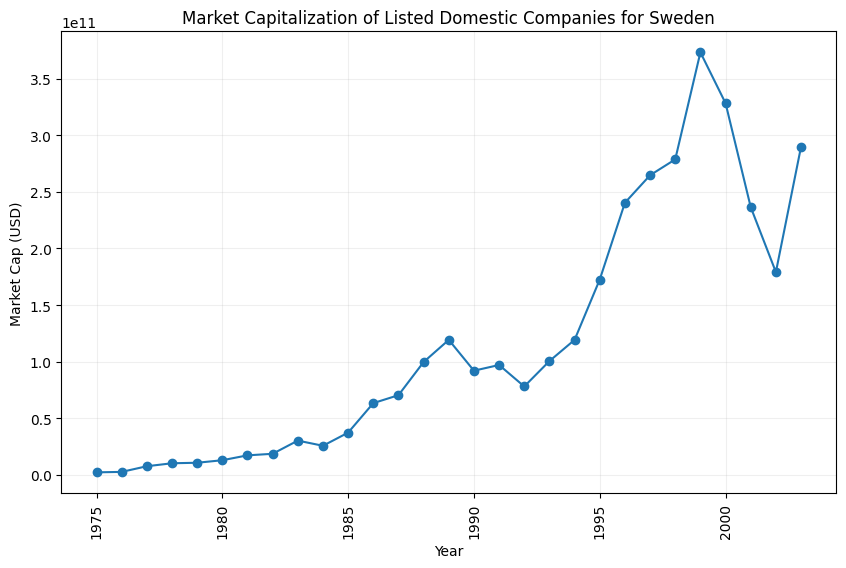

,Year,Market Cap
count,66.000000,2.900000e+01
mean,1992.500000,1.164924e+11
std,19.196354,1.112342e+11
min,1960.000000,2.200010e+09
25%,1976.250000,1.859675e+10
50%,1992.500000,9.201474e+10
75%,2008.750000,1.791174e+11
max,2025.000000,3.732776e+11


In [7]:
# Inspect a country
country = "Sweden"
nor = df_long[df_long['Country Name'] == country].sort_values('Year')
plt.figure(figsize=(10, 6))
plt.plot(nor['Year'], nor['Market Cap'], marker='o')
plt.title(f'Market Capitalization of Listed Domestic Companies for {country}')
plt.xlabel('Year')
plt.ylabel('Market Cap (USD)')
plt.xticks(rotation=90)
plt.grid(alpha=0.2)
# plt.yscale("log")
plt.show()

nor.describe()

In [8]:
# Add iso3 code as the country code
df_long["iso3"] = df_long["Country Code"]

In [9]:
df_long[df_long["iso3"]=="SWE"].groupby("iso3")["Market Cap"].mean()

iso3
SWE    1.164924e+11
Name: Market Cap, dtype: float64

In [10]:
# Export to clean csv
df_long.to_csv("../Clean/market_cap.csv", index=False)

/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_23346/1914864863.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf["Year"] = tf["Year"].astype(int)


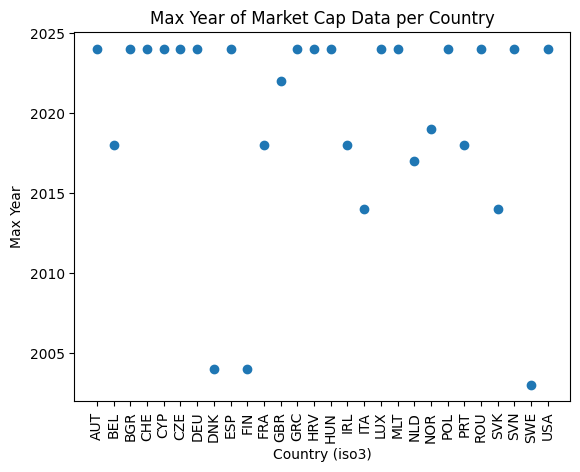

In [11]:
# Give me max year per country
# Fix df_full to only be countries that we have defined it to be
# ── Country set: EU-27 + 4 outside options ────────────────────────────────
EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE          # n = 31

tf = df_long[df_long["iso3"].isin(COUNTRIES)]
tf["Year"] = tf["Year"].astype(int)
tf = tf.dropna(subset=["Market Cap"])
max_yr = tf.groupby("iso3")["Year"].max().reset_index()

plt.figure()
plt.scatter(max_yr["iso3"], max_yr["Year"])
plt.xticks(rotation=90)
plt.title("Max Year of Market Cap Data per Country")
plt.xlabel("Country (iso3)")
plt.ylabel("Max Year")
plt.show()

In [12]:
# Get market cap as a ratio of GDP from PWT
pwt = pd.read_csv("../Clean/pwt.csv")
pwt["Real GDP"] = pwt["Real GDP"] * 1e3
pwt["Capital Stock"] = pwt["Capital Stock"] * 1e3
pwt

,Real GDP,Capital Stock,Worker Population,Total Population,Labour Share,Depreciation Rate,TFP,Interest Rate,Investment Share,Human Capital,countrycode,year
0,3.682509e+05,7.769615e+05,NaN,0.058950,NaN,0.040318,NaN,NaN,0.431354,NaN,ABW,1970
1,4.017193e+05,8.571512e+05,NaN,0.058781,NaN,0.039650,NaN,NaN,0.418163,NaN,ABW,1971
2,4.382295e+05,9.445862e+05,NaN,0.058895,NaN,0.039095,NaN,NaN,0.419161,NaN,ABW,1972
3,4.780579e+05,1.039993e+06,NaN,0.059435,NaN,0.038641,NaN,NaN,0.403070,NaN,ABW,1973
4,5.215061e+05,1.144000e+06,NaN,0.060122,NaN,0.038273,NaN,NaN,0.390737,NaN,ABW,1974
...,...,...,...,...,...,...,...,...,...,...,...,...
11196,4.444503e+07,1.076821e+08,5.272343,15.271368,0.533381,0.059923,1.057740,0.275977,0.130147,2.713408,ZWE,2019
11197,4.097079e+07,1.092483e+08,5.206007,15.526888,0.533381,0.060208,0.973187,0.263760,0.119450,2.746586,ZWE,2020
11198,4.444020e+07,1.109798e+08,5.298346,15.797210,0.533381,0.060136,1.000000,0.205160,0.153113,2.770661,ZWE,2021
11199,4.714755e+07,1.141349e+08,5.344455,16.069056,0.533381,0.059788,0.997026,0.263871,0.172489,2.795292,ZWE,2022


In [35]:
tf = pd.merge(df_long[["iso3", "Year", "Market Cap"]]
              , pwt[["countrycode", "year", "Real GDP", "Capital Stock"]]
              , left_on=["iso3", "Year"]
              , right_on=["countrycode", "year"]
              , how="inner")

# Only COUNTRIES
tf = tf[tf["iso3"].isin(COUNTRIES)]

tf

,iso3,Year,Market Cap,countrycode,year,Real GDP,Capital Stock
2,AUT,1960,NaN,AUT,1960,1.156752e+08,4.246837e+08
4,BEL,1960,NaN,BEL,1960,1.378493e+08,7.022839e+08
14,CHE,1960,NaN,CHE,1960,2.101877e+08,6.462155e+08
25,CYP,1960,NaN,CYP,1960,2.239267e+06,3.127491e+07
26,DEU,1960,NaN,DEU,1960,1.265407e+09,3.372031e+09
...,...,...,...,...,...,...,...
10320,ROU,2023,4.786470e+10,ROU,2023,6.638917e+08,2.350970e+09
10334,SVK,2023,NaN,SVK,2023,1.779981e+08,8.788791e+08
10335,SVN,2023,1.010890e+10,SVN,2023,8.943927e+07,5.805560e+08
10336,SWE,2023,NaN,SWE,2023,6.327961e+08,3.097544e+09


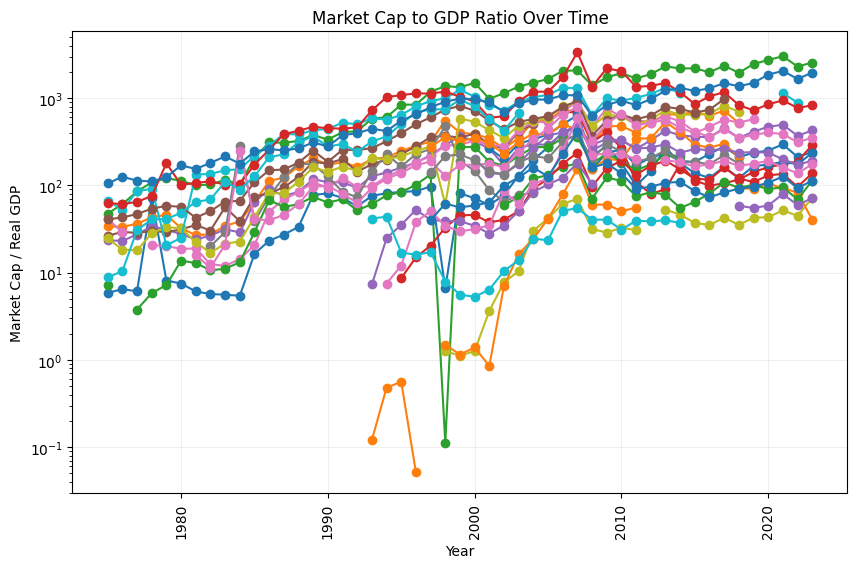

In [37]:
# Plot average per year M/Y
plt.figure(figsize=(10, 6))
for ctr in tf["iso3"].unique():
    subset = tf[tf["iso3"] == ctr]
    plt.plot(subset["Year"], subset["Market Cap"] / subset["Real GDP"], marker='o', label=ctr)
plt.title('Market Cap to GDP Ratio Over Time')
plt.xlabel('Year')
plt.ylabel('Market Cap / Real GDP')
plt.xticks(rotation=90)
plt.grid(alpha=0.2)
plt.yscale("log")
plt.show()

In [38]:
# Use after 2010 to keep the most recent data
# and avoid any structural changes whilst still
# giving a lot of data
tf = tf[tf["Year"] >= 2010]

In [40]:
# Get the proportion of M by Real GDP and by Capital Stock
tf["Market Cap / Real GDP"] = tf["Market Cap"] / tf["Real GDP"]
tf["Market Cap / Capital Stock"] = tf["Market Cap"] / tf["Capital Stock"]
tf[["Market Cap / Real GDP", "Market Cap / Capital Stock"]].describe()

/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_23346/3074572794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf["Market Cap / Real GDP"] = tf["Market Cap"] / tf["Real GDP"]
/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_23346/3074572794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf["Market Cap / Capital Stock"] = tf["Market Cap"] / tf["Capital Stock"]


,Market Cap / Real GDP,Market Cap / Capital Stock
count,279.000000,279.000000
mean,478.720502,106.601532
std,568.250439,135.529294
min,30.799602,6.085689
25%,119.870208,20.680584
50%,237.670119,54.373605
75%,617.447457,121.643378
max,3019.175585,644.974278


In [41]:
tf[["Market Cap", "Capital Stock", "Real GDP"]].apply(np.log).corr()

,Market Cap,Capital Stock,Real GDP
Market Cap,1.000000,0.890980,0.907466
Capital Stock,0.890980,1.000000,0.980134
Real GDP,0.907466,0.980134,1.000000


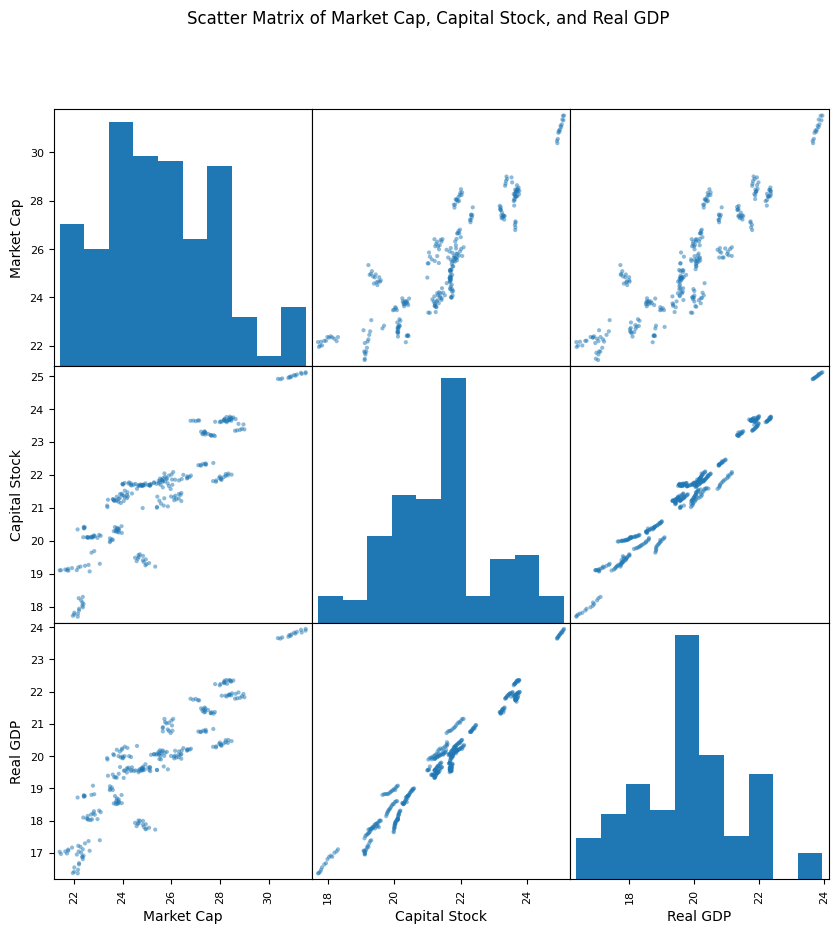

In [42]:
from pandas.plotting import scatter_matrix

scatter_matrix(tf[["Market Cap", "Capital Stock", "Real GDP"]].apply(np.log), figsize=(10, 10))
plt.suptitle("Scatter Matrix of Market Cap, Capital Stock, and Real GDP")
plt.show()

In [43]:
# OLS, smf
import statsmodels.formula.api as smf

# Log-log regression
model = smf.ols("np.log(Q('Market Cap')) ~  np.log(Q('Capital Stock')) + C(iso3) + C(Year)", data=tf).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     np.log(Q('Market Cap'))   R-squared:                       0.993
Model:                                 OLS   Adj. R-squared:                  0.992
Method:                      Least Squares   F-statistic:                     952.7
Date:                     Fri, 17 Apr 2026   Prob (F-statistic):          2.44e-240
Time:                             13:25:18   Log-Likelihood:                 65.740
No. Observations:                      279   AIC:                            -53.48
Df Residuals:                          240   BIC:                             88.14
Df Model:                               38                                         
Covariance Type:                 nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [44]:
# Make a new dataframe that uses the model 
# to fill in the gaps of the market cap data.

df2 = tf.copy()
df2["Market Cap Predicted"] = np.exp(model.predict(df2))
df2[["Market Cap", "Market Cap Predicted"]].describe()

,Market Cap,Market Cap Predicted
count,2.790000e+02,4.340000e+02
mean,1.996940e+12,1.373179e+12
std,7.066953e+12,5.209325e+12
min,1.995750e+09,3.031248e+09
25%,2.091872e+10,2.606703e+10
50%,9.607938e+10,8.965989e+10
75%,7.811116e+11,4.993263e+11
max,4.897940e+13,3.724097e+13


In [45]:
df2

,iso3,Year,Market Cap,countrycode,year,Real GDP,Capital Stock,Market Cap / Real GDP,Market Cap / Capital Stock,Market Cap Predicted
7824,AUT,2010,1.260320e+11,AUT,2010,4.897142e+08,2.652521e+09,257.358213,47.514025,1.137729e+11
7827,BEL,2010,2.687263e+11,BEL,2010,5.605082e+08,3.032535e+09,479.433247,88.614414,3.437195e+11
7831,BGR,2010,7.376360e+09,BGR,2010,1.455786e+08,3.382115e+08,50.669263,21.809905,1.064066e+10
7846,CHE,2010,1.229357e+12,CHE,2010,6.356417e+08,2.912344e+09,1934.040143,422.119203,1.488733e+12
7859,CYP,2010,6.834300e+09,CYP,2010,2.576274e+07,1.912668e+08,265.278478,35.731761,3.661860e+09
...,...,...,...,...,...,...,...,...,...,...
10320,ROU,2023,4.786470e+10,ROU,2023,6.638917e+08,2.350970e+09,72.097152,20.359549,3.103697e+10
10334,SVK,2023,NaN,SVK,2023,1.779981e+08,8.788791e+08,NaN,NaN,7.356977e+09
10335,SVN,2023,1.010890e+10,SVN,2023,8.943927e+07,5.805560e+08,113.025302,17.412446,9.493867e+09
10336,SWE,2023,NaN,SWE,2023,6.327961e+08,3.097544e+09,NaN,NaN,1.518035e+11


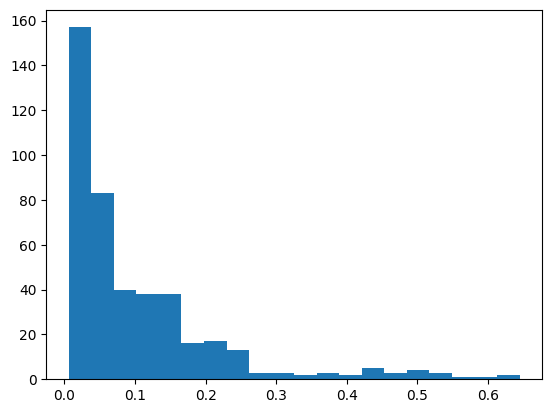

iso3
SVK    0.007336
CZE    0.010244
ROU    0.013195
SVN    0.013934
HUN    0.014181
CYP    0.020231
GRC    0.020452
PRT    0.026872
BGR    0.027679
ITA    0.030106
HRV    0.032015
AUT    0.041404
SWE    0.042945
POL    0.056856
DNK    0.058124
FIN    0.061036
ESP    0.070360
MLT    0.070555
IRL    0.077618
DEU    0.096211
BEL    0.106800
FRA    0.117091
LVA    0.139527
NOR    0.139777
LTU    0.150792
NLD    0.160467
GBR    0.224092
EST    0.226453
LUX    0.235643
USA    0.416477
CHE    0.484611
Name: Market Cap / Capital Stock, dtype: float64

In [53]:
# Show filled M/Y/1e3 and which country has the highest and smallest ratio
insp = df2[["iso3", "Year", "Capital Stock", "Market Cap", "Market Cap Predicted"]].copy()
insp["Market Cap"] = insp["Market Cap"].fillna(insp["Market Cap Predicted"])

# Scale by 1e3
insp["Market Cap"] /= 1e3

insp["Market Cap / Capital Stock"] = insp["Market Cap"] / insp["Capital Stock"]

plt.hist(insp["Market Cap / Capital Stock"], bins=20)
plt.show()

insp.groupby("iso3")["Market Cap / Capital Stock"].mean().sort_values()

In [46]:
# Save it as a new csv
df2.to_csv("../Clean/market_cap_with_predictions.csv", index=False)

## Inspect each country's ratio

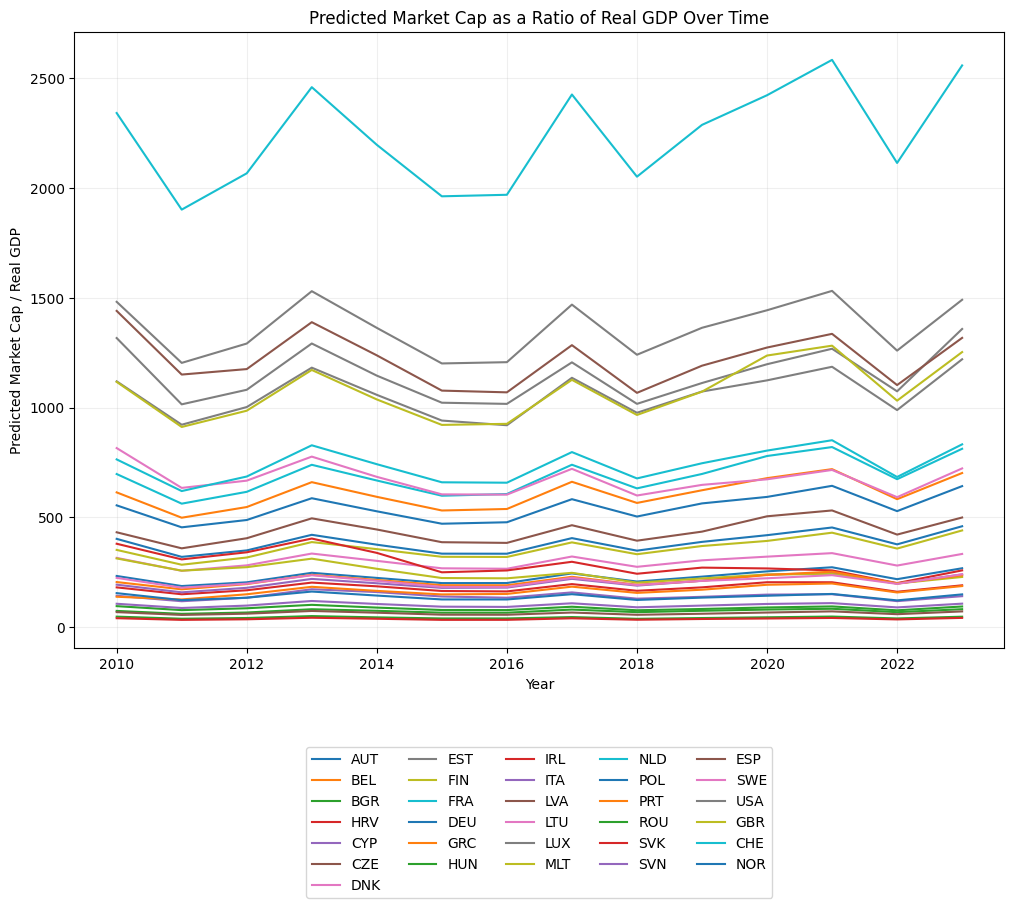

In [47]:
# Make a ratio for each country and see how it changes over time

plt.figure(figsize=(12, 8))

for ctr in COUNTRIES:
    subset = df2[df2["iso3"] == ctr]
    plt.plot(subset["Year"], subset["Market Cap Predicted"] / subset["Real GDP"], label=ctr)

# Add legend below, with five columns
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.title("Predicted Market Cap as a Ratio of Real GDP Over Time")
plt.xlabel("Year")
plt.ylabel("Predicted Market Cap / Real GDP")
plt.grid(alpha=0.2)
plt.show()